# Future additions to the calibration

A list of current weaknesses, etc. that I identified in the approach and which should ideally be solved.

## Mistmatch between the growth curves from empirical data and PnET-Succession (problem with either the empirical data source/statistical modelling, or with things missing in PnET-Succession) 

I had a lot of trouble getting the right match between the growth curves I derived from the NFI (Notebook 4) with the growth curves produces by PnET-Succession. In PnET-Succession, the growth was either too fast but too high; or reached the peak at the right time, but the peak was not high enough. Or the peak height and timing was good, but the species spent the first 50 years of its life almost not growing.

It's difficult to say why; it might be a problem with the NFI data, which is obfuscating the correct grow pattern from the species by averaging, especially because of its space-for-time approach and the percentile identification. Or it could be a problem with PnET-Succession, which is currently (at version 6.0 used to develop these notebooks) missing some key things that influence tree dynamics.

In particular, I'm wondering if young trees tend to have different turnover rates (TOFol, TOWood, TORoot), different allocations (FracFol, FracBelowGround, etc.), and event different photosynthesis structures (FolN, HalfSat) compared to older trees. This would explain why PnET-Succession tend to often produce "S-shaped" growth curves where the growth is first slow (most likely because of a lack of LAI); then much faster; then slows down as it's approaching the peak (because of maintenance costs increasing).

The slow down before the peak is not a problem; but the slower growth at the beginning often don't fit the empirical growth data, which seems (from different sources) to be much "straighter". But this straightness might be a result of how empirical growth data is ultimately modeled other to create growth curves (as in the case of Notebook 4). 

## Calibration step 1.4 or 1.5 : mid-age depression of the growth curve for short-lived species

I removed this calibration step proposed by Gustafson because things were already quite complex. But it might be added in the future to better distinguish species between each other. Here are the info I noted on it :

Focusing on :

- PsnAgeRed
- MaintResp

Some short-lived tree species tend to growth fast at first, but then see their growth slowing down. As such, one might want to reduce growth at their mid-age so that their growth peak is reached more slowly. This can be done through PsnAgeRed, which limits photosynthesis as a function of age. But be careful about the impact of PsnAgeRed on the age of cohort mortality due to senescence (see next section).

One can also act on MaintResp to represent the fact that short-lived species tend to grow fast but have a higher maintenance respiration rate which will depress their growth after a while. Raising MaintResp will therefore depress the curve. But this will make your species more prone to competition mortality, making it more difficult for these species to co-exist together.

## Calibration step 2 : calibration of drought tolerance (H3 and H4)

As I was lacking time, I went with the easiest option to find values of H3 and H4 : to use statistical regression on previously published parameters to link the drought tolerance scores of [Niinemets and Valladares 2006](https://onlinelibrary.wiley.com/doi/abs/10.1890/0012-9615%282006%29076%5B0521%3ATTSDAW%5D2.0.CO%3B2) with the parameters values, so that I can interpolate values for other species.

But I do think that we need to do much better. There doesn't seem to be any empirical values for H3 and H4 in the literature. The previously published parameters use the rule of H3 = H4 based on the idea that photosynthesis brutally stops when dryness of the soil reaches a certain threshold. However, a quick research showed that this is most likely not true; in particular, we now know that there exists a gradient of isohydric/anisohydric species, with the anisohydric species having a much more gradual extinguishment of H3 and H4. As such, the distance between H3 and H4 should change depending on their isohydric/anisohydric status.

In addition to the distance between H3 and H4, their position should most likely also be based on more solid empirical ground. To that end, I think that we can use the way that the drought tolerance scores of [Niinemets and Valladares 2006](https://onlinelibrary.wiley.com/doi/abs/10.1890/0012-9615%282006%29076%5B0521%3ATTSDAW%5D2.0.CO%3B2) are defined. Each score is associated to a) climate conditions where the species is found (precipitations total, variability, etc.); and b) the soil water pressure that the species needs to not be damaged (with the damage being at the least 50% defoliation). We can convert the pressure head of the soil in PnET-Succession into soil water pressure in Megapascals as used by [Niinemets and Valladares 2006](https://onlinelibrary.wiley.com/doi/abs/10.1890/0012-9615%282006%29076%5B0521%3ATTSDAW%5D2.0.CO%3B2) pretty easily by multiplying the absolute pressure head of PnET-Succession (in meters) by `-0.00981`. This gives us a clear target : we should change H3 and H4 so as to reach 50% defoliation (e.g. maximum LAi of the cohort diminishes by 50%) in conditions where we removed the effect on longevity, let the cohort growt to its peak, and then introduced a climate with precipitations low enough to induce a drought that leads to the value in Megapascals proposed by [Niinemets and Valladares 2006](https://onlinelibrary.wiley.com/doi/abs/10.1890/0012-9615%282006%29076%5B0521%3ATTSDAW%5D2.0.CO%3B2). Here is the paragraph from their article that indicates the variations with the drought tolerance score (1 = very intolerant, 5 = very tolerant).

> >The five-level scale used for drought tolerance approximately corresponded with the following values for each category rank: 1, .600 mm precipitation with little variation during growing season, P:PET ratio of .3.0, few days of drought, and greater than 0.3 MPa soil water potential; 2, 500–600 mm precipitation, variation of precipitation distribution during growing season characterized by coefficient of variation ,10%, P:PET ratio of 1.5:3 , few weeks of drought, and from 0.3 to 0.8 MPa soil water potential; 3, 400–500 mm precipitation with a growing season coefficient of variation of 1015%, P:PET ratio of 0.8:1.5, up to one month of drought, and from 0.8 to 1.5 MPa soil water potential; 4, 300–400 mm precipitation with a growing season coefficient of variation of 20–25%, P:PET ratio of 0.5:0.8, two to three months of drought, and from 1.5 to 3 MPa soil water potential; 5, ,300 mm precipitation with a growing season coefficient of variation .25%, P:PET ratio of ,0.5, more than three months of drought, and less than 3 MPa soil water potential.

> Plant physiological potentials are characterized by minimum soil water potential that can be tolerated over the long term with 50% of foliage damage or dieback (Larcher 1994).

One issue remains here : to find the distance between H3 and H4, in terms of pressure head. Since H3 and H4 represent soil pressure head, we would need to have an indication of the change of soil water pressure for different species accross the isohydric/anisohydric gradient between the pressure where photosynthesis starts to drop, and then when it's almost stopped (most often measured with stomatal conductance/stomatal closure). This is the hard part that I haven't found, because most studies look at leaf water pressure versus stomatal conductance, and not soil water pressure; and leaf water pressure =/= soil water pressure. See https://besjournals.onlinelibrary.wiley.com/doi/10.1111/1365-2435.12289 for curves of leaf water pressure versus stomatal conductance; and https://www.nature.com/articles/s41477-025-01957-3 for pre-dawn leaf water pressure (which I've read could be approximated with soil water pressure ? But not certain).

Another issue, highlighted during discussions with Brian Sturtevant : there is a big interaction between how precipitations are modeled in your landscape with PnET-Succession, versus the value of these parameters. PnET-Succession is not always excellent at dealing with hydrology, especially because of the monthly timestep. This can result in water content of soils in the simulated landscape that are quite different from reality (because of lack of spill-over between cells when there is slope, lack of variation between precipitation events, etc.). So it might be quite important to actually calibrate these parameters based on the values of water that are obtain in your landscape (i.e. ensuring that soils that you know tend to be waterlogged in reality are going to affect your species, etc.). This is a big problem, that I sadly don't have the time to deal with for now; we will have to put it as a current limitation.

## Calibration step 2 : calibration of waterlogging tolerance (H1 and H2)

Here again, I think we can improve from the simple regression I've done (see notebook 7).

In particular, I think we can again use the Waterlogging tolerance scores of [Niinemets and Valladares 2006](https://onlinelibrary.wiley.com/doi/abs/10.1890/0012-9615%282006%29076%5B0521%3ATTSDAW%5D2.0.CO%3B2), and use how they are described in the article :

> 5, very tolerant (survives deep, prolonged waterlogging for more than one year); 4, tolerant (survives deep waterlogging for one growing season); 3, moderately tolerant (survives waterlogging or saturated soils for 30 consecutive days during the growing season); 2, intolerant (tolerates one to two weeks of waterlogging during the growing season); 1, very intolerant (does not tolerate water-saturated soils for more than a few days during the growing season).

We can use the survival times to calibrate H1 and H2 so that the cohort survives the given amount of time. But we have two issues : a) we need to figure out the distance between H1 and H2, or when the stress beggings; we could use 3.6 for this (H2 = 3.6), as 3.6m is, according to the user guide, the pressure head under which the soil starts getting saturated for most soil (until we reach 0, which is full saturation). And b) the minimal temporal resolution of PnET-Succession is one month, meaning that we can't make cohorts die quicker than that (problem for tolerances 2 and 1); and c) in PnET-Succession, the "best" we can do to harm a cohort is to set fWater to 0, but that doesn't mean that the cohort will die right when it is set to 0; if the cohort has put Non-structural carbon aside, then it will survive for at least a few month (especially if it is mature). 

Here's what I had in mind as solutions :

a) Set H2 to 3.6. Justification : that's where the pores of the soils start getting filled with water (field capacity). And so, that's where the waterlogging stress will start (because of lack of oxygen in the soil)
b and c) To find the value of H1, first make a curve liking the waterlogging tolerance to the number of days the cohort must survive. Then, find H1 for the maximum tolerance value (365 days or more); for tolerance value of 4 (one growing season, 120 days); and for a tolerance value of 3 (if the cohort survives more than once month because of its NSC, set H1 to 0). That will give you three values of H1 for three different "days of survival" for the species you are calibrating. Use these three values in a linear regression (or GAM if it looks nonlinear) to predict the final value of the exact waterlogging tolerance score of the species. This will work for waterlogging tolerance scores inferior to 3; it will just make the species reach a fWater of 0 before a complete waterlogging. Not perfect, but I think it's quite methodical and defensible.

See also the problem of the water in the soils of the simulated landscape not being always realistic, which means that these parameters should be relative to what's going on in your landscape (see above).

## Calibration step 3 : calibration of competition, generation of uneven-aged structures

When I started working on calibrating the outcome of competition between pair of species, I first thought that we could rely on the following assumption : in the absence of stand-replacing disturbances (i.e. fires, etc.), vegetation dynamics in our pixel will always end up producing an uneven-aged structure. Meaning that the biomass inside the pixel will be distributed across cohorts of different ages.

This assumption is based on what we tend to observe in real life : old forests that haven't been affected by important disturbances tend to get an uneven-aged structure as cohorts of different ages implant and grow at different times in the life of the stand.

However, I wasn't able to replicate this behavior in PnET-Succession. What happenned instead was that the pixel was dominated by one or two cohorts of the same age; no cohort was able to implant while these cohort where alive (i.e. total supression of any growth in the understory of the pixel), and only when the cohorts died was a new single cohort or pair of cohort able to implant, and restarted the cycle. I called this "periodic dominance". This results in a pixel that is almost always even-aged in its composition. After calibrating the parameters in step 1, there is less of this periodic dominance, and things are much more stochastic : the pixels alternate between phases of even-aged structure, and uneven-aged structures. Even-aged structures get re-formed if a cohort gets the opportunity to really capture the light/canopy and suppress everything else. Uneven-aged structure form thanks to the small time lags during which some cohort implant when a dominant cohort is dying.

The only way to obtain a reliable, long-term uneven-aged structure in the pixels with PnET-Succession was to reduce the `k` light extinction coefficient (a species parameter) to allow more light to filter through the leaves of the dominant cohorts. I also had to reduce the timestep of PnET-Succession to increase the number of implantation "opportunities" (as the model tests an implantation of a new cohort once per timestep chosen by the user, and not through the internal monthly timestep of the model). This resulted in younger cohorts implanting here and there, and produced a very messy and chaotic structure which was uneven-aged.

I reflected a lot as if this was a good way to go; and I don't think it is. Doing a bit of research on uneven-aged structures, it seems that they rather form due to the creation of gaps in the forest - which can be large or not so large - through which the light will pass. These gaps can be created by the stochastic mortality of individual trees (diseases, local lack of water or light, etc.), or through partial disturbances (windthrow, insects, etc.). In contrast, when we look at an area of mature forest in which no gaps are present, we tend to see a quite complete suppression of the understory (no younger trees growing). The supression of the understory is also something that seems to be reflected in the litterature and in forestry books; while there can be nuances (some species are better than others at capturing all of the light and preventing growth in the understory), I think it is a pretty good assumption to see that the it is quite normal that the model produces a strong understory supression, and that uneven-aged structures rather appear because of gaps, and not because the understory supression is not complete. Because of this, the strategy of reducing the `k` light extinction coefficient in the model might produce the right results (i.e. it generates an uneven-aged structure on the long term in the pixels), but for the wrong reason. This might impact other more important aspects of the model (photosynthesis, other competition aspects, etc.); for example, it might allow shade intolerant species to grow when they should not. Therefore, I think that this is not the right way to go.

I then asked myself : could we have this "gap dynamic" in PnET-Succession that would generate the uneven-aged structure I was expecting ? After digging into the algorithm, it doesn't seem to be the case, even though PnET-Succession has a very interesting algorithm dealing with light and canopy since v5.1. This algorithm of "Cubic cohorts" is described in [Gustafson et al. (2024)](https://linkinghub.elsevier.com/retrieve/pii/S0304380024000462) (see [](#cubic-cohorts)). The basic idea is this : while LANDIS-II assumes that cohorts have a uniformely distributed biomass/presence inside a pixel, PnET-Succession can still let "gaps" exist in canopy layers by comparing the maximum LAI that a cohort can achieve versus its current LAI. If the cohort is not at its maximum LAI, then there is a gap remaining in the canopy, which can be exploited by another species. Also, when a cohort dies, this leaves a gap that cannot be filled by the cohorts of the current layers; only new cohorts coming from below can come to fill it. It kinda simulate the phenomenon of crown shyness (few superposition of leaf layers in the canopy).

:::{figure}
:label: cubic-cohorts
:align: center

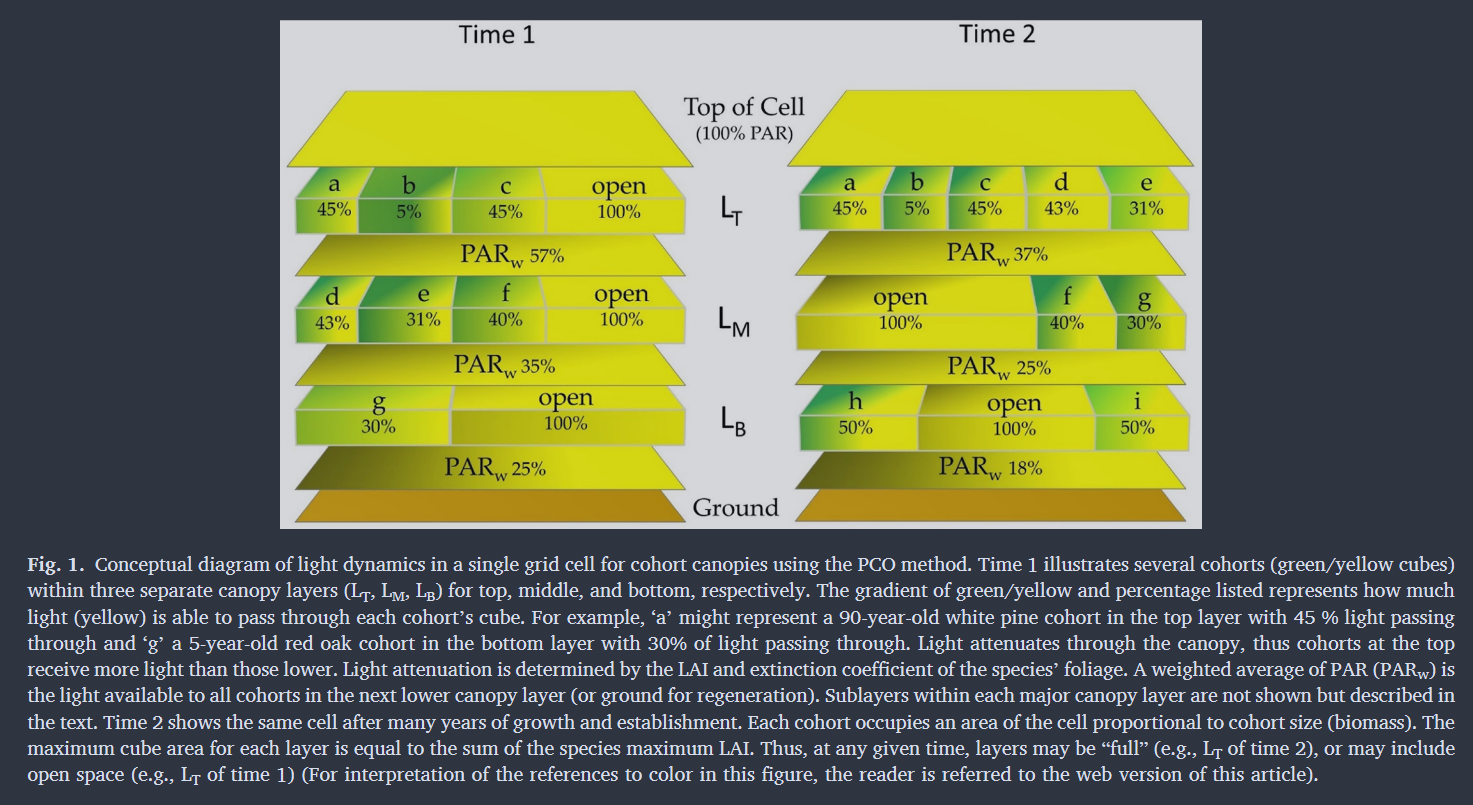

Figure from the article of [Gustafson et al. (2024)](https://linkinghub.elsevier.com/retrieve/pii/S0304380024000462), showing the "cubic cohorts" way of simulating gaps in a canopy. Unfortunately, because the light that comes out of a layer is the average of the transmittance of all cubes in the layer, gaps will not results in very high light conditions when we arrive at the understory.
:::

The limitation of this method is that even though gaps can exist in the canopy, the light that "passes" through a canopy layer will be the average of the light not absorbed by the different cohorts or gaps (as represented by cubes). What that means is that if there is a gap in the canopy, this will not create a spot in the pixel where there are high light conditions, which a young cohort can then use to implant and grow (as would be the case in reality). Instead, the gap will just lower the average of the light that will arrive at the next canopy layer. So if a gap forms in the canopy, it will not create a small patch on the group with 100% light (as in real life); it will instead lower the overall light of the understory or lower layers just a little bit. This reduction will not remove the understory suppression; and therefore, new cohorts will not be able to grow. And thus, we'll still see a dynamic of periodic cohort dominance rather than the creation of an uneven-aged structure.

So, where to go from here ? For this first version of the calibration, I've decided to forgoe forcing the model to produce a stable uneven-aged structure on the long term, while putting two species in competition with each other. I think it's more important to ensure understory suppression and realistic `k` values, rather than forcing the emergence of an uneven-aged structure. Still, in the future, we might try to edit PnET-Succession to add this possibility. I believe it would requires two things : 1. stochastic mortality of cohorts (i.e. parts of the cohort can die, making gaps; this already can happen through different disturbances in LANDIS-II, but maybe we would need a parameter that produces a bit of stochastic mortality at a certain frequency), and 2. the possibility for gaps to create "micro" conditions of high light for a new cohort to implant. This second addition is going to be very difficult, because we're getting into the territory of having to simulate space more explicitly inside the pixels of LANDIS-II. But maybe a way can be found, with inspiration from the cubic cohort approach.

In the meanwhile, I think this problem (of non-emergence of uneven-aged structures in some cases) should be highlighted when interpreting the results. It could be reduced by increasing the resolution of the pixels (more and smaller pixels = more opportunities to simulate tiny gaps in the forest = more heterogeneity = more ways to create uneven-aged structure at a given spatial scale). But I think the current approach can be defended; the model is not perfect, but the model does seem to simulate understory suppression correctly, and it does produce uneven-aged structures by itself (although when it happens, it seems to be quite stochastic and doesn't always last on the long-term. Maybe this is realistic ? It's hard to say, as real forests are affected by many disturbances on the long term, while I'm simulating thousands of years in pixels where nothing happens except growth and senescence).

One last note : this problem is not just with PnET-Succession, and will be present in all succession extension of LANDIS-II, I believe (as all succession extension deal with cohorts in the same way, considering them evenly distributed).

## Calibration step 3 : competition with drought/waterlogging/changed temperatures

When I started this calibration, I aimed to calibrate the drought/waterlogging tolerance of the species (H1, H2, H3, H4) and their temperature tolerance (PsnTMin, PsnTOpt, PsnTMax, LeafOnMin) in the context of competition between them. Meaning, I wanted to make sure that drought tolerant species would survive better than drought-intolerant ones in drought conditions, etc.

I realized with time and testing that this was much more difficult than I initially planned. Especially because it is hard to develop "expected outcomes" for the competition, because so many factors are acting together in PnET-Succession. If you test out a drought tolerant species versus a drought intolerant one, the outcome is dependent on many other things than water availability/drought : there is their respective shade tolerance and timing of establishment, the temperature, etc. 

That's the beauty of PnET-Succession : many factors are interacting at once, as is the case in reality. But this makes developing expected outcome almost impossible, and always relative to a very precise context (i.e. this species will win versus this other, but *only in these particular conditions*). And because we lack empirical data, we cannot test every conditions to ideally/theoretically calibrate species competition by being able to know how species would compete in these varying conditions.

There is always the possibility of temporarely putting the parameters of the two species we are picthing against one another as similar; for example, if I want to test for drought, I can put the temperature parameters at equal values between the two species, and even their shade tolerance parameters. But then, the result will not be very interesting, as we'll simply get the effect of the isolated parameters (e.g. H3 and H4 for drought), and the highest/lowest parameter will win.

All of these issues, added with the fact that I was running out of time, made me decide to focus on obtaining the right values for drought/waterlogging/temperature tolerance in the first place, and let behavior of the species emerge from these values; and trust that the calibration done in step 1 will be enough to adjust the growth in the current conditions of the landscape (especially the temperature/climate).

## Calibration step 0.5 ? : finding temperature parameters (PsnTMin, PSnTOpt, PsnTMax)

These parameters are hard to obtain, because they represent the temperature at which photosynthesis starts (PsnTMin), is optimal (PsnTMax), and stops (PsnTMax). There doesn't seem to be any empirical values for them in the litterature.

Previous studies have used values that are taken from botanical atlases, or from the range of the species distribution. But it's never measures that corresponds well to these parameters, and it's always at the scale of the species - while temperature tolerance might change at a more local level with variants and phenotypes.

I've been digging deep as to how we could improve the computation of these parameters. Especially, I thought about using the data from Morgane's article from theme 1 of DIVERSE ([this one](https://www.sciencedirect.com/science/article/pii/S2666900526000079)) where they computed the percentiles of the coldest month average temp, warmest month average tempt, and annual average temperature for many, many species. Morgane already sent me the data. However, I haven't found any good way to use it yet; maybe to do a regression on published values, again ? I tried using these three variables to build an estimate of the temperatures in the lowest climate the species can accomodate (with low percentile values) for example; but without the growing season length as the key variable, I can't find a good way to estimate the minimum growth temperature from these. And if I used these variables for a simple regression based on published values (like I did with the drought/waterlogging parameters), it doesn't change the fact that published values are not so good.

And then, it hit me : what about dendrochronology ? I'm not well versed, and I know that analysis of tree rings produces estimates of annual growth; but with a bit of digging, it seems to be possible to infer growth at the monthly level. If you correlate it with the monthly historical temperatures for the location where the tree ring was taken, you could estimate the monthly temperature at which growth starts, and at which it stops, and even the optimum !

In fact, there seems to be a model called VS-Lite that helps with this, by simulating tree growth based on climate data and two parameters - T1, the minimum temperature under which there is no growth, and T2, the optimal growth temperature ! Which is exactly what we want. Even better : there is already a published methodology of reverse calibration (i.e. getting these parameter from the tree ring data; see [here](https://cp.copernicus.org/articles/9/1481/2013/cp-9-1481-2013.pdf) ! The method have already been applied in Canada : see [here](https://www.researchgate.net/publication/310668558_Drought_explains_variation_in_the_radial_growth_of_white_spruce_in_western_Canada)) !

So, we could get tree ring data from trees near or even inside our study areas, and get local estimates of these parameters !! Which is great, since we know these parameters can quickly change with local variants ! There's a public database or tree ring data of Canada we could use for that ([TreeSource](https://treesource.rncan.gc.ca/en/faq)).

Other articles :

- [This one](https://www.researchgate.net/publication/228988518_A_forward_modeling_approach_to_paleoclimatic_interpretation_of_tree-ring_data) is an old one (using an older version of VS-lite), but shows some values used for the minimal temperature and optimal temperature and maximal temperature; could be good indicators of where PsnTMin, TMax and TOpt should be.
- [This more recent one](https://www.sciencedirect.com/science/article/abs/pii/S0168192322003835) refers to values of T1 and T2 in their appendices; it's for Asian tree species, and I couldn't download the appendices.
- [This one](https://www.sciencedirect.com/science/article/abs/pii/S1125786515000703), by the authors of the VS model, seem to show a new model where you can do a visual estimation of the parameters by changing them until you fit the data visually.
- [This article](https://cp.copernicus.org/articles/16/1043/2020/) has a lot of T1 and T2 values published in their supp. material; but it seems to be per "site" rather than per species ? Not certain. There are also M1 and M2 estimates, which are related to soil moisture, and which could help for the calibration of the drought tolerance parameters H3 and H4.

I'm putting this here as I will most likely not have the time to do this. In any case, I think these values should be determined before the calibration step 1, as they're going to modifiy what's been done in the step 1.

## Assesment of competition : adjusting the early curve ?

In PnET-Succession, the early competition between species (and even their long-term one) is very influenced by the initial growth rate of each species : the one who will grow the fastest will overtop the other in shade, leading to a dominance.

Sometimes, the calibration made in Notebook 6, based on the biomass peak height and age derived from the growth curves of Notebook 4, tends to produce the wrong competition outcomes for some species (see Notebook 7) because these species grow too slowly or too quickly in their first years compared to the others. We can see this visually in the plots that superpose the growth curve of each species (see the end of Notebook 6).

Ideally, if we want to keep the biomass peak height and age that we obtained from empirical data (see notebook 4), we would need to only change how the beginning of the growth curve is by accelerating or decelerating the initial growth of some species that do not compete properly (undercompete or overcompete), while keep the age and height of their biomass peak the same.

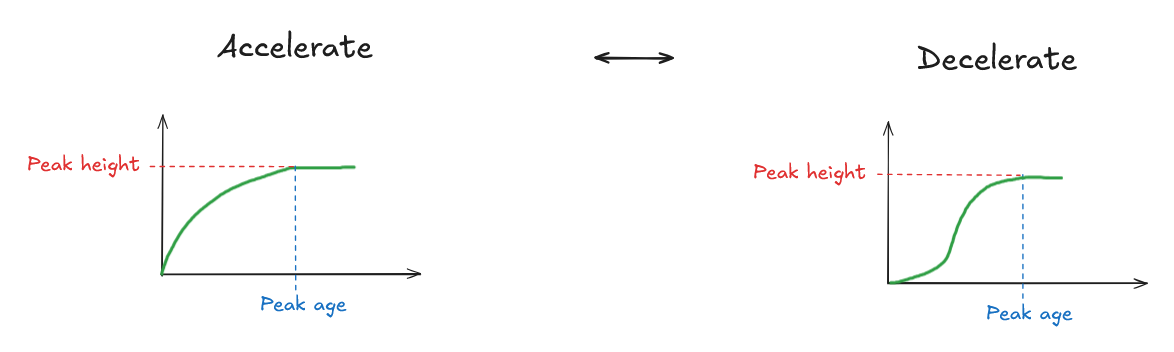

The problem is : this is what's most complicated to do in PnET-Succession in my experience, as there is no proper way (currently) to separatly affect the growth speed in the first years of the species, and the growth speed in its later year. But we need this distinction if we want to change the shape of the curve without affecting the peak age and peak height.

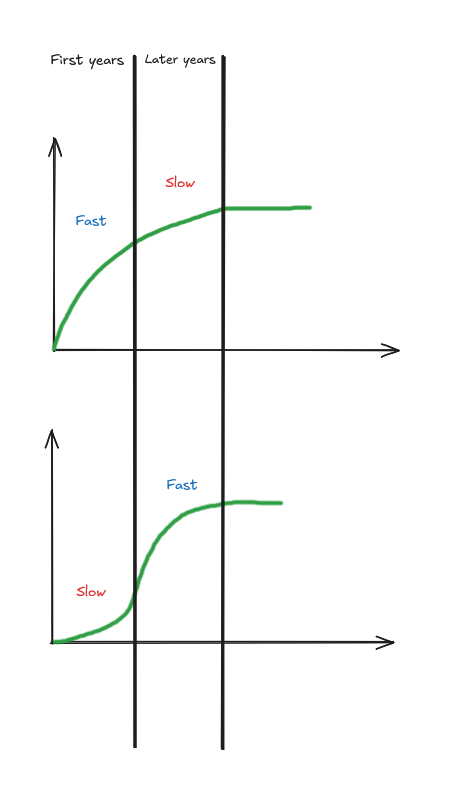

I've worked hard to find a solution to this; I didn't find any. Even by using MaxFracFol/FracFolShape and MaxFolN/FolNShape, I'm not able to influence precisely the beginning of the curve. In the future, it would be great to have parameters that would allow us to do this; maybe by changing the growth only in the first years ? That's what I thought MaxFracFol/FracFolShape and MaxFolN/FolNShape were capable to do, but it seems like they currently influence FracFol and FolN on the long term, no matter the value of FracFolShape or FolNShape we use. It might be a bug, but I'm not sure.


